In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('ai4i2020.csv')  # adjust filename if yours is different
print("Loaded successfully")
print(f"Shape: {df.shape}")

Loaded successfully
Shape: (10000, 14)


In [2]:
df.head()

NameError: name 'df' is not defined

In [11]:
print(df.columns.tolist())

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [13]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [16]:
# How many failures vs non-failures?
print(df['Machine failure'].value_counts())
print(f"\nFailure rate: {df['Machine failure'].mean()*100:.2f}%")

Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


In [18]:
# What product types do we have?
print(df["Type"].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [21]:
# Check for missing values
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [22]:
# Failure breakdown by type
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Failure counts by type:")
print(df[failure_cols].sum())
print(f"\nTotal failures: {df['Machine failure'].sum()}")

Failure counts by type:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Total failures: 339


In [23]:
# Failure rate by product type
print(df.groupby('Type')['Machine failure'].agg(['sum', 'mean', 'count']))

      sum      mean  count
Type                      
H      21  0.020937   1003
L     235  0.039167   6000
M      83  0.027694   2997


In [24]:
# Average process conditions during failure vs no failure
print(df.groupby('Machine failure')[['Air temperature [K]', 
    'Process temperature [K]', 'Rotational speed [rpm]', 
    'Torque [Nm]', 'Tool wear [min]']].mean().round(2))

                 Air temperature [K]  Process temperature [K]  \
Machine failure                                                 
0                             299.97                   310.00   
1                             300.89                   310.29   

                 Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Machine failure                                                        
0                               1540.26        39.63           106.69  
1                               1496.49        50.17           143.78  


In [4]:
# Pareto analysis - which failure types cause most problems?
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_cols].sum().sort_values(ascending=False)
failure_pct = (failure_counts / failure_counts.sum() * 100).round(1)

pareto = pd.DataFrame({
    'Count': failure_counts,
    'Percentage': failure_pct,
    'Cumulative %': failure_pct.cumsum().round(1)
})
print(pareto)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64
     Count  Percentage  Cumulative %
HDF    115        30.8          30.8
OSF     98        26.3          57.1
PWF     95        25.5          82.6
TWF     46        12.3          94.9
RNF     19         5.1         100.0


In [26]:
# Tool wear analysis - at what tool wear level do failures spike?
df['tool_wear_bucket'] = pd.cut(df['Tool wear [min]'], 
    bins=[0, 50, 100, 150, 200, 300], 
    labels=['0-50', '50-100', '100-150', '150-200', '200+'])

wear_analysis = df.groupby('tool_wear_bucket', observed=True)['Machine failure'].agg(
    ['sum', 'mean', 'count']).round(3)
wear_analysis.columns = ['Failures', 'Failure Rate', 'Total Runs']
print(wear_analysis)

                  Failures  Failure Rate  Total Runs
tool_wear_bucket                                    
0-50                    49         0.022        2276
50-100                  53         0.023        2271
100-150                 50         0.022        2295
150-200                 66         0.029        2276
200+                   118         0.155         762


In [27]:
# Torque analysis - at what torque do failures spike?
df['torque_bucket'] = pd.cut(df['Torque [Nm]'], 
    bins=[0, 20, 30, 40, 50, 60, 80], 
    labels=['0-20', '20-30', '30-40', '40-50', '50-60', '60+'])

torque_analysis = df.groupby('torque_bucket', observed=True)['Machine failure'].agg(
    ['sum', 'mean', 'count']).round(3)
torque_analysis.columns = ['Failures', 'Failure Rate', 'Total Runs']
print(torque_analysis)

               Failures  Failure Rate  Total Runs
torque_bucket                                    
0-20                 34         0.146         233
20-30                 9         0.007        1369
30-40                19         0.006        3385
40-50                66         0.019        3472
50-60               112         0.086        1305
60+                  99         0.419         236


In [28]:
# Cost impact calculation
# Assume each failure = 2 hours downtime at £500/hour = £1000 per failure
cost_per_failure = 1000

cost_by_type = df[failure_cols].sum().sort_values(ascending=False)
cost_by_type_gbp = cost_by_type * cost_per_failure

print("Estimated annual downtime cost by failure type:")
for failure, cost in cost_by_type_gbp.items():
    print(f"  {failure}: £{cost:,}")
print(f"\nTotal estimated cost: £{cost_by_type_gbp.sum():,}")

Estimated annual downtime cost by failure type:
  HDF: £115,000
  OSF: £98,000
  PWF: £95,000
  TWF: £46,000
  RNF: £19,000

Total estimated cost: £373,000


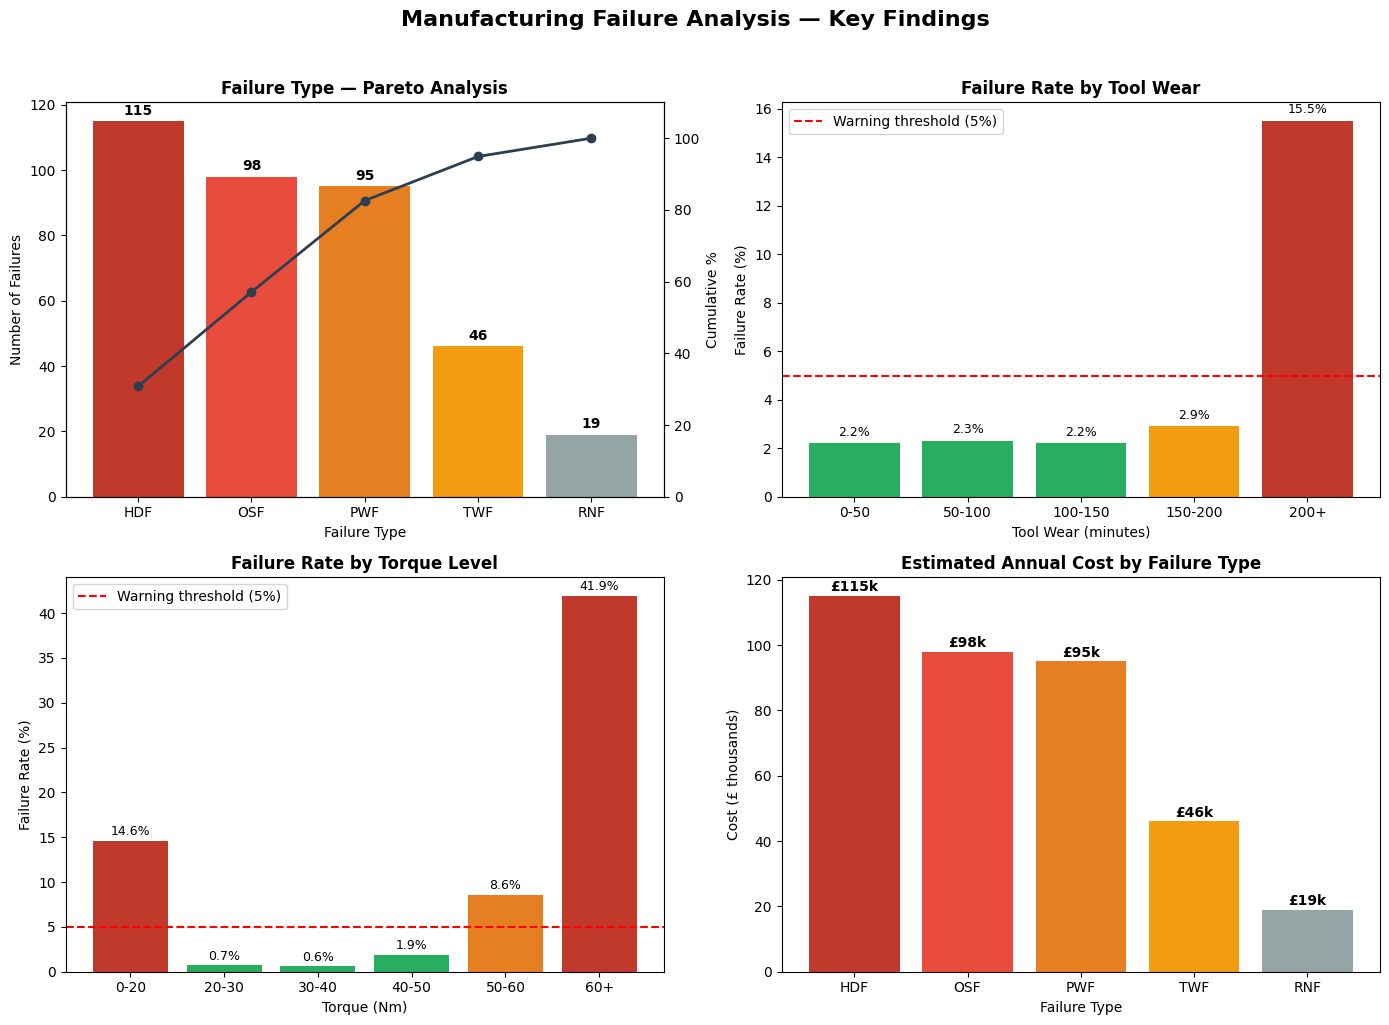

Chart saved as failure_analysis.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Manufacturing Failure Analysis — Key Findings', 
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Pareto of failure types
ax1 = axes[0, 0]
colors = ['#C0392B', '#E74C3C', '#E67E22', '#F39C12', '#95A5A6']
bars = ax1.bar(pareto.index, pareto['Count'], color=colors)
ax2_twin = ax1.twinx()
ax2_twin.plot(pareto.index, pareto['Cumulative %'], 
              color='#2C3E50', marker='o', linewidth=2)
ax2_twin.set_ylabel('Cumulative %', fontsize=10)
ax2_twin.set_ylim(0, 110)
ax1.set_title('Failure Type — Pareto Analysis', fontweight='bold')
ax1.set_ylabel('Number of Failures')
ax1.set_xlabel('Failure Type')
for bar, count in zip(bars, pareto['Count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(count), ha='center', va='bottom', fontweight='bold')

# Chart 2 — Tool wear failure rate
ax2 = axes[0, 1]
wear_colors = ['#27AE60', '#27AE60', '#27AE60', '#F39C12', '#C0392B']
bars2 = ax2.bar(wear_analysis.index, 
                wear_analysis['Failure Rate'] * 100, color=wear_colors)
ax2.set_title('Failure Rate by Tool Wear', fontweight='bold')
ax2.set_ylabel('Failure Rate (%)')
ax2.set_xlabel('Tool Wear (minutes)')
ax2.axhline(y=5, color='red', linestyle='--', 
            linewidth=1.5, label='Warning threshold (5%)')
ax2.legend()
for bar, rate in zip(bars2, wear_analysis['Failure Rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.2,
             f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 3 — Torque failure rate
ax3 = axes[1, 0]
torque_colors = ['#C0392B', '#27AE60', '#27AE60', 
                 '#27AE60', '#E67E22', '#C0392B']
bars3 = ax3.bar(torque_analysis.index, 
                torque_analysis['Failure Rate'] * 100, color=torque_colors)
ax3.set_title('Failure Rate by Torque Level', fontweight='bold')
ax3.set_ylabel('Failure Rate (%)')
ax3.set_xlabel('Torque (Nm)')
ax3.axhline(y=5, color='red', linestyle='--', 
            linewidth=1.5, label='Warning threshold (5%)')
ax3.legend()
for bar, rate in zip(bars3, torque_analysis['Failure Rate']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 4 — Cost by failure type
ax4 = axes[1, 1]
cost_colors = ['#C0392B', '#E74C3C', '#E67E22', '#F39C12', '#95A5A6']
bars4 = ax4.bar(cost_by_type_gbp.index, 
                cost_by_type_gbp.values / 1000, color=cost_colors)
ax4.set_title('Estimated Annual Cost by Failure Type', fontweight='bold')
ax4.set_ylabel('Cost (£ thousands)')
ax4.set_xlabel('Failure Type')
for bar, cost in zip(bars4, cost_by_type_gbp.values):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'£{cost/1000:.0f}k', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as failure_analysis.png")

In [30]:
df.to_csv('ai4i_clean.csv', index=False)
print("Clean data saved")

Clean data saved


In [5]:
import sqlite3

# Create a database file
conn = sqlite3.connect('manufacturing.db')

# Load your clean dataframe into the database as a table
df.to_sql('machine_data', conn, if_exists='replace', index=False)

print("Database created and data loaded successfully")
print(f"Rows loaded: {len(df)}")

Database created and data loaded successfully
Rows loaded: 10000


In [6]:
# Verify the table exists and looks right
check = pd.read_sql("SELECT * FROM machine_data LIMIT 5", conn)
print(check)

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [9]:
query1 = """
SELECT 
    'HDF' AS failure_type,
    SUM(HDF) AS failure_count,
    ROUND(SUM(HDF) * 100.0 / COUNT(*), 2) AS failure_rate_pct,
    SUM(HDF) * 1000 AS estimated_cost_gbp
FROM machine_data

UNION ALL

SELECT 
    'OSF',
    SUM(OSF),
    ROUND(SUM(OSF) * 100.0 / COUNT(*), 2),
    SUM(OSF) * 1000
FROM machine_data

UNION ALL

SELECT 
    'PWF',
    SUM(PWF),
    ROUND(SUM(PWF) * 100.0 / COUNT(*), 2),
    SUM(PWF) * 1000
FROM machine_data

UNION ALL

SELECT 
    'TWF',
    SUM(TWF),
    ROUND(SUM(TWF) * 100.0 / COUNT(*), 2),
    SUM(TWF) * 1000
FROM machine_data

UNION ALL

SELECT 
    'RNF',
    SUM(RNF),
    ROUND(SUM(RNF) * 100.0 / COUNT(*), 2),
    SUM(RNF) * 1000
FROM machine_data

ORDER BY failure_count DESC
"""

result1 = pd.read_sql(query1, conn)
print("QUERY 1 — Failure count, rate and cost by type:")
print(result1)

QUERY 1 — Failure count, rate and cost by type:
  failure_type  failure_count  failure_rate_pct  estimated_cost_gbp
0          HDF            115              1.15              115000
1          OSF             98              0.98               98000
2          PWF             95              0.95               95000
3          TWF             46              0.46               46000
4          RNF             19              0.19               19000


In [10]:
query2 = """
SELECT
    CASE
        WHEN "Tool wear [min]" BETWEEN 0 AND 49 THEN '1. 0-50 mins'
        WHEN "Tool wear [min]" BETWEEN 50 AND 99 THEN '2. 50-100 mins'
        WHEN "Tool wear [min]" BETWEEN 100 AND 149 THEN '3. 100-150 mins'
        WHEN "Tool wear [min]" BETWEEN 150 AND 199 THEN '4. 150-200 mins'
        ELSE '5. 200+ mins'
    END AS tool_wear_band,
    COUNT(*) AS total_runs,
    SUM("Machine failure") AS failures,
    ROUND(SUM("Machine failure") * 100.0 / COUNT(*), 2) AS failure_rate_pct
FROM machine_data
GROUP BY tool_wear_band
ORDER BY tool_wear_band
"""

result2 = pd.read_sql(query2, conn)
print("QUERY 2 — Failure rate by tool wear band:")
print(result2)

QUERY 2 — Failure rate by tool wear band:
    tool_wear_band  total_runs  failures  failure_rate_pct
0     1. 0-50 mins        2349        52              2.21
1   2. 50-100 mins        2271        51              2.25
2  3. 100-150 mins        2290        52              2.27
3  4. 150-200 mins        2289        61              2.66
4     5. 200+ mins         801       123             15.36


In [11]:
query3 = """
SELECT
    CASE
        WHEN "Torque [Nm]" BETWEEN 0 AND 19.99 THEN '1. 0-20 Nm'
        WHEN "Torque [Nm]" BETWEEN 20 AND 29.99 THEN '2. 20-30 Nm'
        WHEN "Torque [Nm]" BETWEEN 30 AND 39.99 THEN '3. 30-40 Nm'
        WHEN "Torque [Nm]" BETWEEN 40 AND 49.99 THEN '4. 40-50 Nm'
        WHEN "Torque [Nm]" BETWEEN 50 AND 59.99 THEN '5. 50-60 Nm'
        ELSE '6. 60+ Nm'
    END AS torque_band,
    COUNT(*) AS total_runs,
    SUM("Machine failure") AS failures,
    ROUND(SUM("Machine failure") * 100.0 / COUNT(*), 2) AS failure_rate_pct
FROM machine_data
GROUP BY torque_band
ORDER BY torque_band
"""

result3 = pd.read_sql(query3, conn)
print("QUERY 3 — Failure rate by torque band:")
print(result3)

QUERY 3 — Failure rate by torque band:
   torque_band  total_runs  failures  failure_rate_pct
0   1. 0-20 Nm         228        34             14.91
1  2. 20-30 Nm        1348         9              0.67
2  3. 30-40 Nm        3364        19              0.56
3  4. 40-50 Nm        3487        66              1.89
4  5. 50-60 Nm        1334       111              8.32
5    6. 60+ Nm         239       100             41.84


In [12]:
query4 = """
SELECT
    Type AS product_type,
    COUNT(*) AS total_runs,
    SUM("Machine failure") AS failures,
    ROUND(SUM("Machine failure") * 100.0 / COUNT(*), 2) AS failure_rate_pct,
    SUM("Machine failure") * 1000 AS estimated_cost_gbp
FROM machine_data
GROUP BY Type
ORDER BY failure_rate_pct DESC
"""

result4 = pd.read_sql(query4, conn)
print("QUERY 4 — Failure rate by product type:")
print(result4)

QUERY 4 — Failure rate by product type:
  product_type  total_runs  failures  failure_rate_pct  estimated_cost_gbp
0            L        6000       235              3.92              235000
1            M        2997        83              2.77               83000
2            H        1003        21              2.09               21000


In [13]:
query5 = """
SELECT
    UDI AS run_id,
    "Product ID" AS product_id,
    Type AS product_type,
    "Tool wear [min]" AS tool_wear_mins,
    "Torque [Nm]" AS torque_nm,
    "Rotational speed [rpm]" AS speed_rpm,
    "Machine failure" AS failed,
    CASE
        WHEN TWF = 1 THEN 'Tool Wear'
        WHEN HDF = 1 THEN 'Heat Dissipation'
        WHEN PWF = 1 THEN 'Power'
        WHEN OSF = 1 THEN 'Overstrain'
        WHEN RNF = 1 THEN 'Random'
        ELSE 'No failure'
    END AS failure_cause
FROM machine_data
WHERE "Machine failure" = 1
    AND "Tool wear [min]" > 200
    AND "Torque [Nm]" > 50
ORDER BY "Tool wear [min]" DESC, "Torque [Nm]" DESC
LIMIT 10
"""

result5 = pd.read_sql(query5, conn)
print("QUERY 5 — Top 10 highest risk runs (high wear AND high torque):")
print(result5)

QUERY 5 — Top 10 highest risk runs (high wear AND high torque):
   run_id product_id product_type  tool_wear_mins  torque_nm  speed_rpm  \
0    5402     M20261            M             253       54.8       1454   
1    5400     H34813            H             246       53.8       1411   
2    5395     M20254            M             234       70.5       1262   
3    9665     L56844            L             231       54.8       1317   
4    2859     L50038            L             231       51.5       1417   
5    4033     L51212            L             231       50.3       1383   
6    4384     L51563            L             229       65.5       1298   
7    4644     L51823            L             228       54.2       1324   
8    1336     L48515            L             228       53.8       1371   
9    4643     L51822            L             226       54.6       1238   

   failed     failure_cause  
0       1         Tool Wear  
1       1        Overstrain  
2       1           

In [14]:
sql_queries = """
-- Manufacturing Failure Analysis
-- Dataset: AI4I 2020 Predictive Maintenance
-- Author: Ashkan Mirzahoseini

-- QUERY 1: Failure count, rate and cost by failure type
SELECT 
    'HDF' AS failure_type,
    SUM(HDF) AS failure_count,
    ROUND(SUM(HDF) * 100.0 / COUNT(*), 2) AS failure_rate_pct,
    SUM(HDF) * 1000 AS estimated_cost_gbp
FROM machine_data
UNION ALL
SELECT 'OSF', SUM(OSF), ROUND(SUM(OSF) * 100.0 / COUNT(*), 2), SUM(OSF) * 1000 FROM machine_data
UNION ALL
SELECT 'PWF', SUM(PWF), ROUND(SUM(PWF) * 100.0 / COUNT(*), 2), SUM(PWF) * 1000 FROM machine_data
UNION ALL
SELECT 'TWF', SUM(TWF), ROUND(SUM(TWF) * 100.0 / COUNT(*), 2), SUM(TWF) * 1000 FROM machine_data
UNION ALL
SELECT 'RNF', SUM(RNF), ROUND(SUM(RNF) * 100.0 / COUNT(*), 2), SUM(RNF) * 1000 FROM machine_data
ORDER BY failure_count DESC;


-- QUERY 2: Failure rate by tool wear band
SELECT
    CASE
        WHEN "Tool wear [min]" BETWEEN 0 AND 49 THEN '1. 0-50 mins'
        WHEN "Tool wear [min]" BETWEEN 50 AND 99 THEN '2. 50-100 mins'
        WHEN "Tool wear [min]" BETWEEN 100 AND 149 THEN '3. 100-150 mins'
        WHEN "Tool wear [min]" BETWEEN 150 AND 199 THEN '4. 150-200 mins'
        ELSE '5. 200+ mins'
    END AS tool_wear_band,
    COUNT(*) AS total_runs,
    SUM("Machine failure") AS failures,
    ROUND(SUM("Machine failure") * 100.0 / COUNT(*), 2) AS failure_rate_pct
FROM machine_data
GROUP BY tool_wear_band
ORDER BY tool_wear_band;


-- QUERY 3: Failure rate by torque band
SELECT
    CASE
        WHEN "Torque [Nm]" BETWEEN 0 AND 19.99 THEN '1. 0-20 Nm'
        WHEN "Torque [Nm]" BETWEEN 20 AND 29.99 THEN '2. 20-30 Nm'
        WHEN "Torque [Nm]" BETWEEN 30 AND 39.99 THEN '3. 30-40 Nm'
        WHEN "Torque [Nm]" BETWEEN 40 AND 49.99 THEN '4. 40-50 Nm'
        WHEN "Torque [Nm]" BETWEEN 50 AND 59.99 THEN '5. 50-60 Nm'
        ELSE '6. 60+ Nm'
    END AS torque_band,
    COUNT(*) AS total_runs,
    SUM("Machine failure") AS failures,
    ROUND(SUM("Machine failure") * 100.0 / COUNT(*), 2) AS failure_rate_pct
FROM machine_data
GROUP BY torque_band
ORDER BY torque_band;


-- QUERY 4: Failure rate and cost by product type
SELECT
    Type AS product_type,
    COUNT(*) AS total_runs,
    SUM("Machine failure") AS failures,
    ROUND(SUM("Machine failure") * 100.0 / COUNT(*), 2) AS failure_rate_pct,
    SUM("Machine failure") * 1000 AS estimated_cost_gbp
FROM machine_data
GROUP BY Type
ORDER BY failure_rate_pct DESC;


-- QUERY 5: Top 10 highest risk runs (high tool wear AND high torque)
SELECT
    UDI AS run_id,
    "Product ID" AS product_id,
    Type AS product_type,
    "Tool wear [min]" AS tool_wear_mins,
    "Torque [Nm]" AS torque_nm,
    "Rotational speed [rpm]" AS speed_rpm,
    "Machine failure" AS failed,
    CASE
        WHEN TWF = 1 THEN 'Tool Wear'
        WHEN HDF = 1 THEN 'Heat Dissipation'
        WHEN PWF = 1 THEN 'Power'
        WHEN OSF = 1 THEN 'Overstrain'
        WHEN RNF = 1 THEN 'Random'
        ELSE 'No failure'
    END AS failure_cause
FROM machine_data
WHERE "Machine failure" = 1
    AND "Tool wear [min]" > 200
    AND "Torque [Nm]" > 50
ORDER BY "Tool wear [min]" DESC, "Torque [Nm]" DESC
LIMIT 10;
"""

with open('manufacturing_analysis.sql', 'w') as f:
    f.write(sql_queries)

print("SQL file saved as manufacturing_analysis.sql")

SQL file saved as manufacturing_analysis.sql


In [15]:
conn.close()
print("Database connection closed")

Database connection closed


In [16]:
# Check rows where RNF=1 and what other failures they have simultaneously
rnf_rows = df[df['RNF'] == 1]
print(f"Total RNF rows: {len(rnf_rows)}")
print("\nOther failures on same rows:")
print(rnf_rows[['TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']].sum())

Total RNF rows: 19

Other failures on same rows:
TWF                 1
HDF                 0
PWF                 0
OSF                 0
RNF                19
Machine failure     1
dtype: int64
